### Convolution
###### 이미지 위에서 stride 값만큼 filter를 이동시키면서 겹쳐지는 부분의 각 원소의 값을 곱해서 모두 더한 값을 출력하는 연산

#### Convolution filter 선언하는 방법
- torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride = 1, padding = 0, bias = True)
- ex) conv = nn.Conv2d(1, 1, 3)  --> 입력 채널 1, 출력 채널 1, 커널 크기 3*3

----

#### 입력의 형태
- input type : torch.Tensor
- input shape : (N * C * H * W) (batch_size, channel, height, width)

----

#### MaxPooling 계층 선언
- torch.nn.MaxPool2d(kernel_size) (나머지는 Default 값이어서 따르 지정 안 해줘도 됨)

----
##### 모델 구조

- fully connected layer 전에 view()로 배치 수 빼고 다 펼쳐줘야 한다.

-----

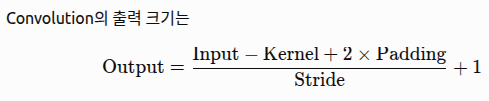

----

In [10]:
import torch
import torch.nn as nn

input = torch.Tensor(1, 1, 28, 28)
conv1 = nn.Conv2d(1, 32, 3, padding = 1)
pool1 = nn.MaxPool2d(2)
conv2 = nn.Conv2d(32, 64, 3, padding = 1)
pool2 = nn.MaxPool2d(2)

out1 = conv1(input)
out1.shape
out2 = pool1(out1)
out3 = conv2(out2)
out4 = pool2(out3)
out4.shape

torch.Size([1, 64, 7, 7])

In [18]:
import torch
import torch.nn as nn
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import torch.nn.init

device = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed(777)

learning_rate = 0.001
training_epochs = 15
batch_size = 100

mnist_train = dsets.MNIST(root = 'MNIST_data/',
                          train = True,
                          transform = transforms.ToTensor(),
                          download = True)

mnist_test = dsets.MNIST(root = 'MNIST_data/',
                         train = False,
                         transform = transforms.ToTensor(),
                         download = True)

data_loader = torch.utils.data.DataLoader(dataset = mnist_train,
                                          batch_size = batch_size,
                                          shuffle = True,
                                          drop_last = True)

class CNN(nn.Module):

    def __init__(self):

        super(CNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Linear(7 * 7 * 64, 10, bias = True)
        torch.nn.init.xavier_normal(self.fc.weight)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)

        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

model = CNN().to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

total_batch = len(data_loader)

for epoch in range(training_epochs):
    avg_cost = 0

    for X, Y in data_loader:
        X = X.to(device)
        Y = Y.to(device)


        optimizer.zero_grad()
        hypothesis = model(X)

        cost = criterion(hypothesis, Y)
        cost.backward()
        optimizer.step()

        avg_cost += cost / total_batch

    print('Epoch: {}, cost: {}'.format(epoch + 1, avg_cost))
print('Learning Finished')


/tmp/ipykernel_116801/1132261751.py:50: FutureWarning: `nn.init.xavier_normal` is now deprecated in favor of `nn.init.xavier_normal_`.
  torch.nn.init.xavier_normal(self.fc.weight)


Epoch: 1, cost: 0.21192894876003265
Epoch: 2, cost: 0.06205856055021286
Epoch: 3, cost: 0.04547073319554329
Epoch: 4, cost: 0.0368540994822979
Epoch: 5, cost: 0.03092174232006073
Epoch: 6, cost: 0.025980595499277115
Epoch: 7, cost: 0.021293049678206444
Epoch: 8, cost: 0.018072735518217087
Epoch: 9, cost: 0.014892508275806904
Epoch: 10, cost: 0.012350048869848251
Epoch: 11, cost: 0.0105635030195117
Epoch: 12, cost: 0.010942036285996437
Epoch: 13, cost: 0.00745984073728323
Epoch: 14, cost: 0.005636499263346195
Epoch: 15, cost: 0.006012630183249712
Learning Finished


-----

### CNN을 이용한 image 학습하기
    1. 내가 가진 사진을 이용해서 dataset 만들기

In [2]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from matplotlib.pyplot import imshow
%matplotlib inline

trans = transforms.Compose([
    transforms.Resize((64,128))
])

train_data = torchvision.datasets.ImageFolder(root ='custom_data/origin_data', transform = trans)

for num, value in enumerate(train_data):
    data, label = value
    print(num, data, label)

    if(label == 0):
        data.save('custom_data/train_data/gray/%d_%d.jpeg'%(num, label))
    else:
        data.save('custom_data/train_data/red/%d_%d.jpeg'%(num, label))







0 <PIL.Image.Image image mode=RGB size=128x64 at 0x7B7A0DFD44C0> 0
1 <PIL.Image.Image image mode=RGB size=128x64 at 0x7B7A0DFD4A30> 0
2 <PIL.Image.Image image mode=RGB size=128x64 at 0x7B78B65F6260> 0
3 <PIL.Image.Image image mode=RGB size=128x64 at 0x7B7A0DFD5DB0> 0
4 <PIL.Image.Image image mode=RGB size=128x64 at 0x7B78B65F7880> 0
5 <PIL.Image.Image image mode=RGB size=128x64 at 0x7B7A0DFD5C00> 0
6 <PIL.Image.Image image mode=RGB size=128x64 at 0x7B78C3FCEAD0> 0
7 <PIL.Image.Image image mode=RGB size=128x64 at 0x7B78B65F7880> 0
8 <PIL.Image.Image image mode=RGB size=128x64 at 0x7B7A0DFD5DB0> 0
9 <PIL.Image.Image image mode=RGB size=128x64 at 0x7B78C3FCEAD0> 0
10 <PIL.Image.Image image mode=RGB size=128x64 at 0x7B78B65F7880> 0
11 <PIL.Image.Image image mode=RGB size=128x64 at 0x7B7A0DFD4100> 0
12 <PIL.Image.Image image mode=RGB size=128x64 at 0x7B78C3FCEAD0> 0
13 <PIL.Image.Image image mode=RGB size=128x64 at 0x7B78B65F7880> 0
14 <PIL.Image.Image image mode=RGB size=128x64 at 0x7B7A0D

-------

    2. 내 사진을 분류하는 딥러닝 모델 학습

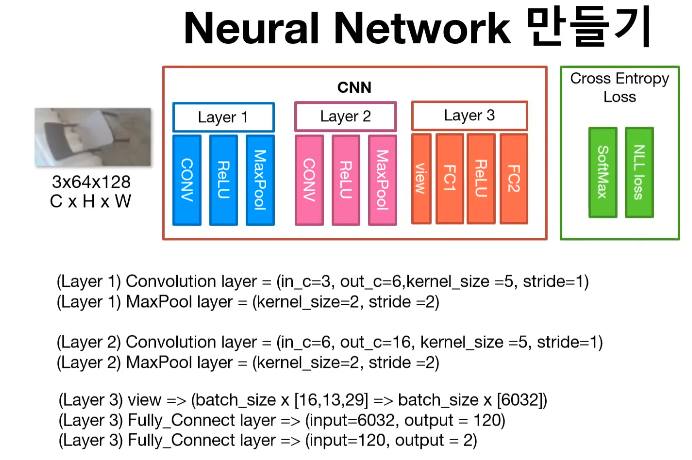

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

device = 'cuda' if torch.cuda.is_available() else 'cpu'

trans = transforms.Compose([
    transforms.ToTensor()
])

train_data = torchvision.datasets.ImageFolder(root = './custom_data/train_data', transform = trans)
data_loader = DataLoader(dataset = train_data, batch_size = 8, shuffle = True, num_workers = 2)

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 6, 5, stride = 1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(6, 16, 5, stride = 1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(6032, 120),
            nn.ReLU(),
            nn.Linear(120, 2)
        )

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.shape[0], -1)
        out = self.layer3(out)
        return out

net = CNN()
optimizer = optim.Adam(net.parameters(), lr = 0.0005)
loss_func = nn.CrossEntropyLoss()

total_batch = len(data_loader)
epochs = 3
for epoch in range(epochs):
    avg_cost = 0.0
    for num, data in enumerate(data_loader):
        imgs, labels = data
        optimizer.zero_grad()
        out = net(imgs)
        loss = loss_func(out, labels)
        loss.backward()
        optimizer.step()

        avg_cost += loss / total_batch

    print('Epoch: {} cost = {}'.format(epoch + 1, avg_cost))
print('Learning Finished!')

torch.save(net.state_dict(), "./custom_data/model/model.pth")
new_net = CNN()
new_net.load_state_dict(torch.load('./custom_data/model/model.pth'))

print(net.layer1[0])
print(new_net.layer1[0])

print(net.layer1[0].weight[0][0][0])
print(new_net.layer1[0].weight[0][0][0])

net.layer1[0].weight[0] == new_net.layer1[0].weight[0]

trans = torchvision.transforms.Compose([
    transforms.Resize((64,128)),
    transforms.ToTensor()
])
test_data = torchvision.datasets.ImageFolder(root = './custom_data/test_data', transform = trans)
test_set = DataLoader(dataset = test_data, batch_size = len(test_data))

with torch.no_grad():
    for num, data in enumerate(test_set):
        imgs, label = data
        prediction = net(imgs)
        correct_prediction = torch.argmax(prediction, 1) == label

        accuracy = correct_prediction.float().mean()
        print('Accuracy: ', accuracy.item())



Epoch: 1 cost = 0.18648993968963623
Epoch: 2 cost = 0.003170377342030406
Epoch: 3 cost = 0.0007633704226464033
Learning Finished!
Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
tensor([ 0.0502,  0.0556,  0.0898, -0.0644, -0.0760],
       grad_fn=<SelectBackward0>)
tensor([ 0.0502,  0.0556,  0.0898, -0.0644, -0.0760],
       grad_fn=<SelectBackward0>)
Accuracy:  1.0


---------

### VGG 만들기

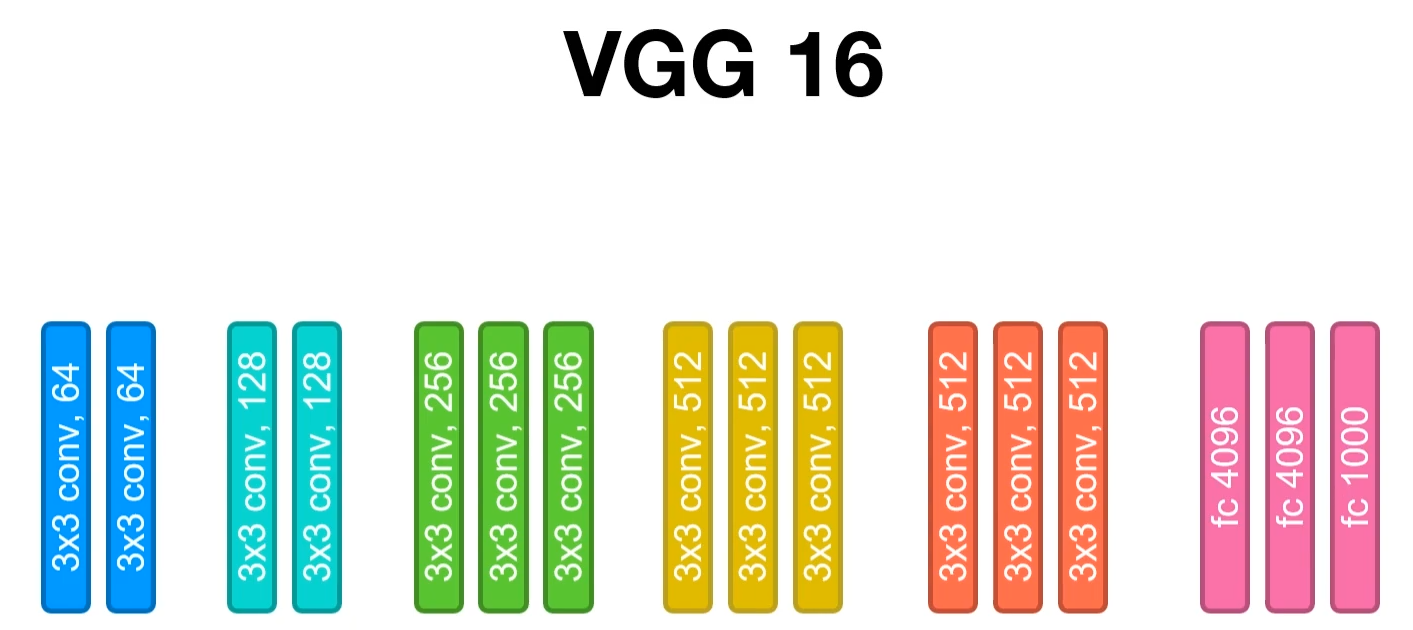

- Convolution layer가 모두 3*3으로 되어있다.(커널 사이즈를 고정함으로써 파라미터 개수와 연산량을 줄였다.)
- torchvision.models.vgg에서 입력을 3 * 244 * 244 기준으로 만들도록 되어있다.

In [ ]:
import torch
import torch.nn as nn


class VGG(nn.Module):
    def __init__(
        self,
        features,
        num_classes=1000,
        init_weights=True
    ):
        super(VGG, self).__init__()

        self.features = features

        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))

        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(),

            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),

            nn.Linear(4096, num_classes)
        )

        if init_weights:
            self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)

        # (batch, 512, 7, 7) → (batch, 512 * 7 * 7)
        x = x.view(x.size(0), -1)

        x = self.classifier(x)

        return x

    def _initialize_weights(self):
        for m in self.modules():

            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode='fan_out',
                    nonlinearity='relu'
                )

                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

            elif isinstance(m, nn.Linear):
                nn.init.normal_(
                    m.weight,
                    mean=0,
                    std=0.01
                )
                nn.init.constant_(m.bias, 0)

def make_layers(cfg, batch_norm=False): # cfg에 따라 어떤 layers를 만들지 바뀐다.
    layers = []
    in_channels = 3

    for v in cfg:
        if v == 'M':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        else:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)

            if batch_norm:
                    layers += [
                        conv2d,
                        nn.BatchNorm2d(v),
                        nn.ReLU(inplace=True)
                    ]
            else:
                    layers += [
                        conv2d,
                        nn.ReLU(inplace=True)
                    ]

            in_channels = v

    return nn.Sequential(*layers)

cfg = {
    'A': [64, 'M', 128, 'M', 256, 256, 'M',
        512, 512, 'M', 512, 512, 'M'],

    'B': [64, 64, 'M', 128, 128, 'M',
          256, 256, 'M',
          512, 512, 'M',
          512, 512, 'M'],

    'D': [64, 64, 'M', 128, 128, 'M',
          256, 256, 256, 'M',
          512, 512, 512, 'M',
          512, 512, 512, 'M'],

    'E': [64, 64, 'M', 128, 128, 'M',
          256, 256, 256, 256, 'M',
          512, 512, 512, 512, 'M',
          512, 512, 512, 512, 'M']
            }


CNN = VGG(features = make_layers(cfg['A']), num_classes = 10, init_weights= True)

------

### ResNet

###### 매우 깊은 신경망에서도 학습이 잘 되도록 만든 CNN 구조다.
###### 기존에는 네트워크가 깊어질수록 기울기 소실과 성능 저하문제가 발생했다.
###### 이를 고치기 해결하기 위해 ShorCut이라는 기법을 사용


##### ShorCut
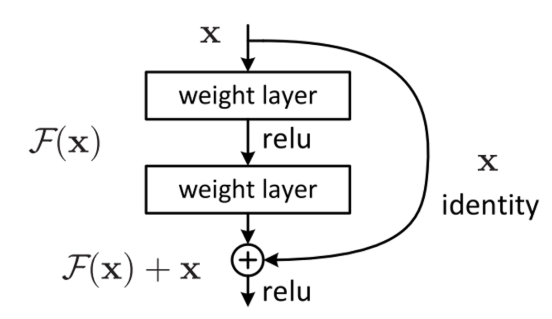

- 쓰는 이유: 처음부터 입력이 특징을 잘 살릴수도 있다. 즉 전부를 학습해서 낭비하지 말고 기존 입력에 필요한 부분들만 수정하자.
- 즉, 마지막에 forward()해서 나온 변화량을 기존의 입력에 더해주는 구조다.

##### 두 가지 Block 사용법

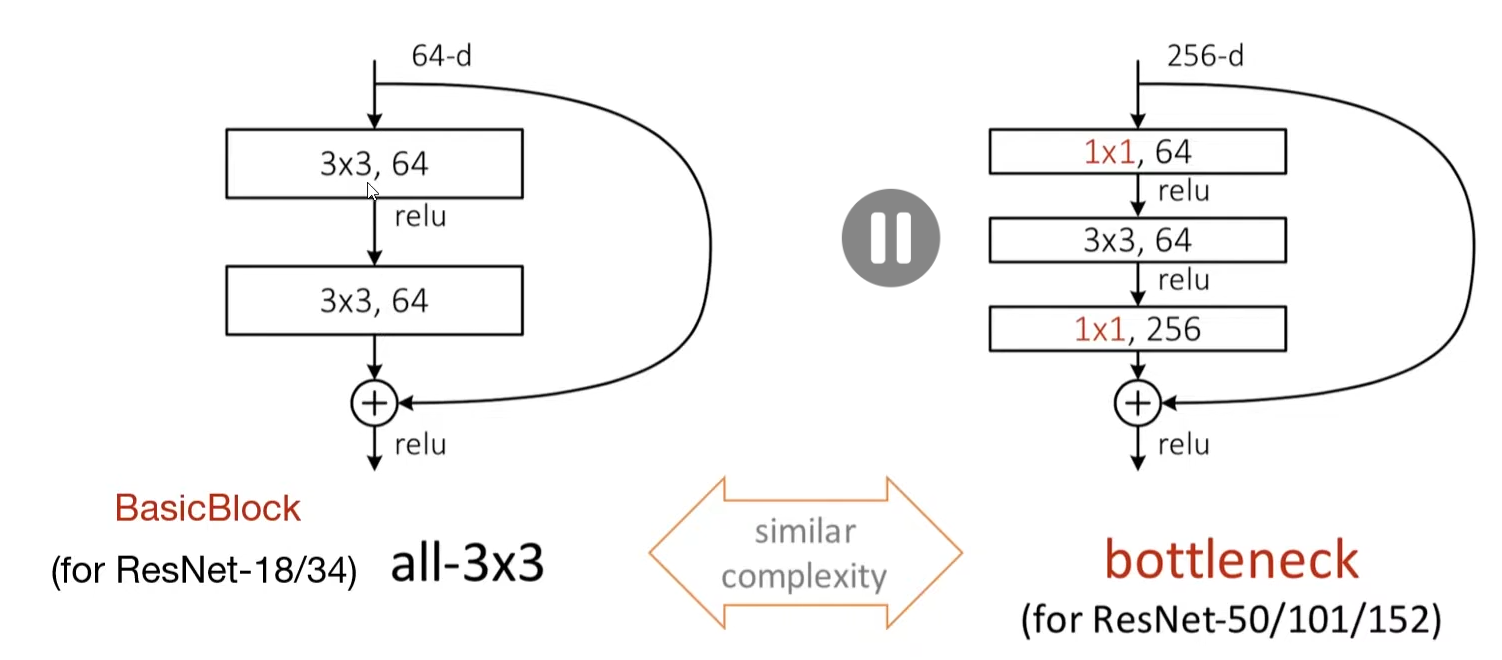
- Residual Block은 채널 수를 계속 유지하면서 계산을 하여 간단하다는 장점이 있지만 채널 수가 커질수록 필터를 지날 때 계산량이 많아진다는 단점이 있다는 반면에,
- Bottle Neck Residual Block은 채널 수를 1*1 필터를 지나면서 줄이고 줄인 상태로 필터 계산을 하기 때문에 계산량이 줄어든다는 장점이 있는 반면에 네트워크가 복잡하다는 단점이 있다. 

- 무조건 Bottle Neck이 좋은게 아니라 모델마다 사용하는 Block이 다르다.


- ResNet은 이 Block들을 여러 번 이어붙인 구조로 되어있다.

In [7]:
import torch.nn as nn
import torch.utils.model_zoo as model_zoo

def conv3X3(in_planes, out_planes, stride = 1):
    return nn.Conv2d(in_planes, out_planes, kernel_size = 3, stride = stride, padding = 1, bias = False)

def conv1X1(in_planes, out_planes, stride = 1):
    return nn.Conv2d(in_planes, out_planes, kernel_size = 1, stride = stride, bias = False)



class BasicBlock(nn.Module):
    expansion = 1 # expansion은 마지막에 나오는 채널 수 planes에 곱하는 수인데 왜 곱하냐?(입력 채널 수랑 맞혀야 하기 때문에)

    def __init__(self, inplanes, planes, stride = 1, downsample = None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3X3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace = True)
        self.conv2 = conv3X3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)


        out += identity
        out = self.relu(out)

        return out
    

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride = 1, downsample = None):
        super(Bottleneck, self).__init__()
        self.conv1 = conv1X1(inplanes, planes)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = conv3X3(planes, planes, stride)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = conv1X1(planes, planes * self.expansion, stride)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)
        self.relu = nn.ReLU(inplace = True)
        self.downsample = downsample
        self.stride = stride


    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return  out


class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes = 1000, zero_init_residual = False):

        super(ResNet,self).__init__()
        self.inplanes = 64 # 입력 채널 값

        self.conv1 = nn.Conv2d(3, 64, kernel_size = 7, stride = 2, padding = 3, bias = False)

        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace = True) # inplace = True 라는 것은 메모리에서 그 값을 직접 바꾼다는 말
        self.maxpool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride = 2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride = 2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride = 2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode = 'fan_out', nonlinearity = 'relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def _make_layer(self, block, planes, blocks, stride = 1):

        downsample = None

        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1X1(self.inplanes, planes * block.expansion, stride),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))

        self.inplanes = planes * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x




-------

### ResNet을 이용해서 CIFAR-10 학습시키기




In [3]:
import torch.nn as nn
import torch.utils.model_zoo as model_zoo

def conv3X3(in_planes, out_planes, stride = 1):
    return nn.Conv2d(in_planes, out_planes, kernel_size = 3, stride = stride, padding = 1, bias = False)

def conv1X1(in_planes, out_planes, stride = 1):
    return nn.Conv2d(in_planes, out_planes, kernel_size = 1, stride = stride, bias = False)



class BasicBlock(nn.Module):
    expansion = 1 # expansion은 마지막에 나오는 채널 수 planes에 곱하는 수인데 왜 곱하냐?(입력 채널 수랑 맞혀야 하기 때문에)

    def __init__(self, inplanes, planes, stride = 1, downsample = None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3X3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace = True)
        self.conv2 = conv3X3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)


        out += identity
        out = self.relu(out)

        return out
    

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride = 1, downsample = None):
        super(Bottleneck, self).__init__()
        self.conv1 = conv1X1(inplanes, planes)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = conv3X3(planes, planes, stride)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = conv1X1(planes, planes * self.expansion)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)
        self.relu = nn.ReLU(inplace = True)
        self.downsample = downsample
        self.stride = stride


    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return  out


class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes = 1000, zero_init_residual = False):

        super(ResNet,self).__init__()
        self.inplanes = 64 # 입력 채널 값

        self.conv1 = nn.Conv2d(3, 64, kernel_size = 3, stride = 1, padding = 1, bias = False)

        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace = True) # inplace = True 라는 것은 메모리에서 그 값을 직접 바꾼다는 말
        self.maxpool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride = 2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride = 2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride = 2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode = 'fan_out', nonlinearity = 'relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def _make_layer(self, block, planes, blocks, stride = 1):

        downsample = None

        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1X1(self.inplanes, planes * block.expansion, stride),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))

        self.inplanes = planes * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        # x = self.maxpool(x) CIFAR-10은 이미 많이 작기 때문에 초기 MaxPool은 하지 않는다.

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x


def resnet50_cifar10():
        return ResNet(
            block=Bottleneck,
            layers=[3, 4, 6, 3],
            num_classes=10
        )

model = resnet50_cifar10().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4
)

lr_sche = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)



In [2]:
import torch
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("사용 장치", device)

train_transform = transforms.Compose([
    transforms.RandomCrop(
        32,
        padding=4
    ),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])


test_transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])


trainset = torchvision.datasets.CIFAR10(
    root="./cifar10",
    train=True,
    download=False,
    transform=train_transform
)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=256,
                                          shuffle=True, num_workers=0)

testset = torchvision.datasets.CIFAR10(
    root="./cifar10",
    train=False,
    download=False,
    transform=test_transform
)

testloader = torch.utils.data.DataLoader(testset, batch_size=256,
                                         shuffle=False, num_workers=0)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

사용 장치 cuda


In [8]:
# eval 코드
def acc_check(net, test_set, epoch, save=True):
    net.eval()

    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in test_set:
            images = images.to(device)
            labels = labels.to(device)

            outputs = net(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)

            predicted = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (
                predicted == labels
            ).sum().item()

    acc = 100 * correct / total
    test_loss = running_loss / total

    print(
        f"Epoch {epoch + 1} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Accuracy: {acc:.2f}%"
    )

    # W&B를 사용하고 있을 때만 활성화
    # wandb.log(
    #     {
    #         "test/loss": test_loss,
    #         "test/accuracy": acc
    #     },
    #     step=epoch
    # )

    if save:
        torch.save(
            net.state_dict(),
            f"./model_epoch_{epoch + 1}_acc_{acc:.2f}.pth"
        )

    return test_loss, acc

In [ ]:
# 학습 
epochs = 5

train_loss_history = []
test_loss_history = []
test_acc_history = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    total_loss = 0.0
    total_samples = 0

    for i, data in enumerate(trainloader):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)

        running_loss += loss.item()
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        if i % 30 == 29:
            avg_loss = running_loss / 30

            print(
                f"[{epoch + 1}, {i + 1}] "
                f"loss: {avg_loss:.3f}"
            )

            # W&B를 사용할 때만 활성화
            # wandb.log(
            #     {"train/batch_loss": avg_loss}
            # )

            running_loss = 0.0

    train_loss = total_loss / total_samples

   

    # 한 epoch 학습이 끝난 뒤 학습률 변경
    lr_sche.step()

print("Finished Training")



test_loss, test_acc = acc_check(
    model,
    testloader,
    epoch,
    save=True
)

[1, 30] loss: 1.465
[1, 60] loss: 1.430
[1, 90] loss: 1.433
[1, 120] loss: 1.415
[1, 150] loss: 1.396
[1, 180] loss: 1.375
[2, 30] loss: 1.331
[2, 60] loss: 1.302
[2, 90] loss: 1.273
[2, 120] loss: 1.241
[2, 150] loss: 1.225
[2, 180] loss: 1.243
[3, 30] loss: 1.177
[3, 60] loss: 1.172
[3, 90] loss: 1.136
[3, 120] loss: 1.120
[3, 150] loss: 1.082
[3, 180] loss: 1.098
[4, 30] loss: 1.060
[4, 60] loss: 1.021
[4, 90] loss: 1.007
[4, 120] loss: 1.038
[4, 150] loss: 1.018
[4, 180] loss: 1.012
[5, 30] loss: 0.988
[5, 60] loss: 0.933
[5, 90] loss: 0.930
[5, 120] loss: 0.908
[5, 150] loss: 0.889
[5, 180] loss: 0.889
Finished Training
Finished Training
Epoch 5 | Test Loss: 0.9472 | Test Accuracy: 66.66%
